<a href="https://www.kaggle.com/code/shoshanamiriamlevin/iwoa-liquaor-mixlm-by-yaakov-levin?scriptVersionId=311798112" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iowa-liquor-sales/Iowa_Liquor_Sales.csv


In [2]:
csv_path='/kaggle/input/iowa-liquor-sales/Iowa_Liquor_Sales.csv'

In [3]:
import duckdb
con=duckdb.connect()
print('it worked')

it worked


In [4]:
con.execute(f"""
CREATE OR REPLACE TABLE sales_data AS
SELECT
    UPPER(TRIM("City")) AS City,
    UPPER(TRIM("Store Name")) AS Store_Name,
    CAST(REPLACE(REPLACE("Volume Sold (Liters)", '$', ''), ',', '') AS DOUBLE) AS Volume,
    UPPER(TRIM("County")) AS County,
    UPPER(TRIM("Item Description")) AS Item,
    -- This handles the $ and , in the price
    CAST(REPLACE(REPLACE("State Bottle Cost", '$', ''), ',', '') AS DOUBLE) AS Unit_Cost,
    MONTHNAME(CAST("Date" AS DATE)) AS Month,
    YEAR(CAST("Date" AS DATE)) AS Year,
    -- This handles the $ and , in the total sale
    CAST(REPLACE(REPLACE("Sale (Dollars)", '$', ''), ',', '') AS DOUBLE) AS Sales
FROM read_csv_auto('{csv_path}', types={{'State Bottle Cost': 'VARCHAR', 'Sale (Dollars)': 'VARCHAR', 'Volume Sold (Liters)': 'VARCHAR'}})
WHERE "City" IS NOT NULL
""")


print(con.execute("SELECT City, Item, Unit_Cost, Sales FROM sales_data LIMIT 5").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         City                                   Item  Unit_Cost   Sales
0   WEST BEND             SMIRNOFF VODKA 80 PRF MINI       7.47   11.20
1       BOONE                  KESSLER BLEND WHISKEY      11.02   99.18
2   DAVENPORT                              99 APPLES       7.80   11.70
3     CLINTON  JOSE CUERVO ESPECIAL REPOSADO TEQUILA      10.49  188.76
4  DES MOINES                            ST. GERMAIN      18.99  170.94


we chose these colunms because we can analyze these colunms to see wich city is the best to bring liquar for wich city needs more bottels there to see if there diffrent times of years sre better to see if having stores aree the whole reason big stores aree better or not

In [5]:
side=""" 
SELECT SUM(Sales) as total_sales,SUM(Volume) as total_volune,COUNT(*) AS total_sold,Item
FROM sales_data
GROUP BY Item
ORDER BY total_sales DESC
LIMIT 10
"""
df1 = con.execute(side).df()

In [6]:
df1.head()


,total_sales,total_volune,total_sold,Item
0,1.494204e+08,8.272297e+06,378012,TITOS HANDMADE VODKA
1,1.424305e+08,1.524104e+07,687299,BLACK VELVET
2,9.066304e+07,5.617448e+06,401468,FIREBALL CINNAMON WHISKEY
3,7.644558e+07,2.522677e+06,229227,CROWN ROYAL
4,7.312765e+07,4.336954e+06,210583,CAPTAIN MORGAN SPICED RUM


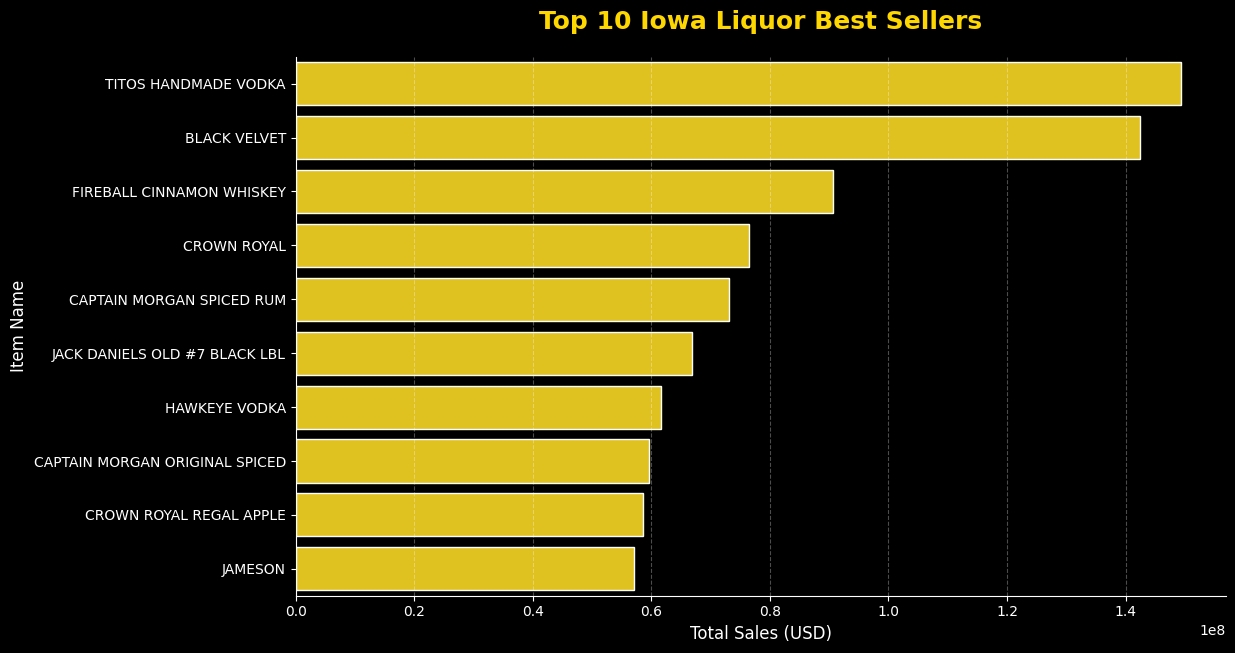

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the dark aesthetic
plt.style.use('dark_background')
plt.figure(figsize=(12, 7))

# Create the bar plot
# We'll use a single gold color for a clean 'luxury' look
ax = sns.barplot(
    x='total_sales', 
    y='Item', 
    data=df1, 
    color='#FFD700',  # Gold hex code
    edgecolor='white'
)

# Customizing the labels and title
plt.title('Top 10 Iowa Liquor Best Sellers', fontsize=18, pad=20, color='#FFD700', fontweight='bold')
plt.xlabel('Total Sales (USD)', fontsize=12, color='white')
plt.ylabel('Item Name', fontsize=12, color='white')

# Remove the top and right spines for a modern look
sns.despine()

# Add a grid on the x-axis only to help readability
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Save the figure as requested
plt.savefig('iowa_liquor_best_sellers.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


In [8]:
main=f"""
   SELECT 
        City,
        County,
        Month,
        Year,
        COUNT(DISTINCT Store_Name) AS total_places,
        COUNT(*) AS total_transactions,
        SUM(Sales) AS Total_Sales
    FROM sales_data
    GROUP BY City, County, Month, Year,
    ORDER BY Total_Sales desc
"""

df = con.execute(main).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
df.head()

,City,County,Month,Year,total_places,total_transactions,Total_Sales
0,DES MOINES,POLK,December,2022,87,20542,5186000.18
1,DES MOINES,POLK,June,2023,82,20789,4879545.57
2,DES MOINES,POLK,May,2023,82,18590,4846800.84
3,DES MOINES,POLK,April,2021,78,20456,4835732.45
4,DES MOINES,POLK,May,2022,77,18120,4781858.05


In [10]:

df['temp_date'] = df['Month'] + " 1, " + df['Year'].astype(str)
df['date'] = pd.to_datetime(df['temp_date'])
df.head(1)

,City,County,Month,Year,total_places,total_transactions,Total_Sales,temp_date,date
0,DES MOINES,POLK,December,2022,87,20542,5186000.18,"December 1, 2022",2022-12-01


In [11]:
df.drop(columns='temp_date',inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55229 entries, 0 to 55228
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   City                55229 non-null  object        
 1   County              54783 non-null  object        
 2   Month               55229 non-null  object        
 3   Year                55229 non-null  int64         
 4   total_places        55229 non-null  int64         
 5   total_transactions  55229 non-null  int64         
 6   Total_Sales         55229 non-null  float64       
 7   date                55229 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 3.4+ MB


In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [14]:
df['Monthly_Id']=df['date'].dt.year*12+df["date"].dt.month
df.head()


,City,County,Month,Year,total_places,total_transactions,Total_Sales,date,Monthly_Id
0,DES MOINES,POLK,December,2022,87,20542,5186000.18,2022-12-01,24276
1,DES MOINES,POLK,June,2023,82,20789,4879545.57,2023-06-01,24282
2,DES MOINES,POLK,May,2023,82,18590,4846800.84,2023-05-01,24281
3,DES MOINES,POLK,April,2021,78,20456,4835732.45,2021-04-01,24256
4,DES MOINES,POLK,May,2022,77,18120,4781858.05,2022-05-01,24269


In [15]:
df['Sales_Millions'] = df['Total_Sales'] / 1_000_000

# Update your formula
gee_model = sm.GEE.from_formula("Sales_Millions ~ Monthly_Id + Month", 
                                groups="City", 
                                data=df, 
                                cov_struct=sm.cov_struct.Exchangeable())
gee_results = gee_model.fit()

In [16]:
gee_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:              Sales_Millions   No. Observations:                55229
Model:                                 GEE   No. clusters:                      481
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                 371
Family:                           Gaussian   Mean cluster size:               114.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Wed, 15 Apr 2026   Scale:                           0.063
Covariance type:                    robust   Time:                         13:11:50
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -8.9538      1.638     -5.465      0.000     -12.165      -5.743
Month[T.August]        0.0026      0.001      2.893      0.004       0.001       0.004
Month[T.December]      0.0196      0.003      5.967      0.000       0.013       0.026
Month[T.February]     -0.0054      0.001     -5.482      0.000      -0.007      -0.003
Month[T.January]      -0.0080      0.002     -5.344      0.000      -0.011      -0.005
Month[T.July]      -5.946e-07      0.001     -0.001      1.000      -0.002       0.002
Month[T.June]          0.0065      0.001      4.793      0.000       0.004       0.009
Month[T.March]        -0.0012      0.001     -2.264      0.024      -0.002      -0.000
Month[T.May]           0.0046      0.001      5.190      0.000       0.003       0.006
Month[T.November]      0.0036      0.001      3.613      0.000       0.002       0.006
Month[T.October]       0.0167      0.003      5.081      0.000       0.010       0.023
Month[T.September]     0.0024      0.001      2.543      0.011       0.001       0.004
Monthly_Id             0.0004    6.8e-05      5.469      0.000       0.000       0.001
==============================================================================
Skew:                          9.1096   Kurtosis:                     113.5380
Centered skew:                -5.2893   Centered kurtosis:            254.3930
==============================================================================
"""

we see that months are very important also sales are important 
but sales dont follow a normall curve 
we see that december and october have high sales but january have lower 

In [17]:
print("GEE Coefficients:\n", gee_results.params)

GEE Coefficients:
 Intercept            -8.953780e+00
Month[T.August]       2.553936e-03
Month[T.December]     1.957411e-02
Month[T.February]    -5.353163e-03
Month[T.January]     -8.049105e-03
Month[T.July]        -5.945735e-07
Month[T.June]         6.516947e-03
Month[T.March]       -1.243399e-03
Month[T.May]          4.581817e-03
Month[T.November]     3.583818e-03
Month[T.October]      1.665238e-02
Month[T.September]    2.395799e-03
Monthly_Id            3.717492e-04
dtype: float64


In [18]:
liquor_model1 = smf.mixedlm("Total_Sales ~ Monthly_Id+C(Month)", 
                           data=df, 
                           groups=df["City"])

liquor_results1 = liquor_model1.fit()
print(liquor_results1.summary())

                         Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          Total_Sales    
No. Observations:          55229            Method:                      REML           
No. Groups:                481              Scale:                       7779867042.4072
Min. group size:           1                Log-Likelihood:              -708684.1942   
Max. group size:           371              Converged:                   Yes            
Mean group size:           114.8                                                        
----------------------------------------------------------------------------------------
                           Coef.       Std.Err.     z    P>|z|    [0.025       0.975]   
----------------------------------------------------------------------------------------
Intercept                -8939452.757 237305.525 -37.671 0.000 -9404563.039 -8474342.475
C(Month)[T.August]           2553.208   1803.21

Seasonality is Significant: The model indicates that specific months have a substantial impact on sales compared to the baseline. Specifically, December and January show strong, statistically significant positive coefficients ($p < 0.001$).The year-end peak in December shows a massive increase of 19,573.25, though sales do see a decrease in January relative to that December high. Additionally, June shows a strongly significant increase of 6,514.84. While this mid-year bump is not as large as the December peak, it still represents a substantial impact on overall sales. 

In [19]:

liquor_model2 = smf.mixedlm("Total_Sales~ Monthly_Id+C(Month)+total_places", 
                           data=df, 
                           groups=df["City"])

liquor_results2 = liquor_model2.fit()
print(liquor_results2.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        Total_Sales    
No. Observations:          55229          Method:                    REML           
No. Groups:                481            Scale:                     3180361022.4566
Min. group size:           1              Log-Likelihood:            -683695.5745   
Max. group size:           371            Converged:                 Yes            
Mean group size:           114.8                                                    
------------------------------------------------------------------------------------
                          Coef.       Std.Err.     z    P>|z|    [0.025     0.975]  
------------------------------------------------------------------------------------
Intercept                  58894.846 154798.045   0.380 0.704 -244503.747 362293.439
C(Month)[T.August]          3175.796   1152.919   2.755 0.006     916.116   5435.477
C(Mo

"While city size and the number of retail outlets are the primary drivers of liquor sales (adding ~$1,400 per location), significant seasonal surges in August and September suggest that consumer demand is heavily influenced by external events and holidays, regardless of the city's scale."

there is no signifit trend on time as but its due to citiesthere many citys that sell a lot more in iowa

In [20]:

v_inter = liquor_results2.cov_re.iloc[0, 0] 
v_resid = liquor_results2.scale

# 2. Calculate ICC using the correct variable names
icc = v_inter / (v_inter + v_resid)
print(f"City Variance: {v_inter}")
print(f"Residual Variance: {v_resid}")
print(f"ICC: {icc:.4f}")

City Variance: 5315611502.190909
Residual Variance: 3180361022.4566164
ICC: 0.6257


In [21]:
two=f"""
WITH CityStats AS (
    SELECT 
        City, 
        Item, 
        SUM(Sales) as total_item_sales,
        AVG(Sales) as avg_sale,
        STDDEV(Sales) as sales_volatility
    FROM sales_data
    WHERE Month IN ('December', 'June') -- Focusing on your peak months
    GROUP BY City, Item
)
SELECT 
    City, 
    Item, 
    ROUND(total_item_sales, 2) as Sept_Revenue,
    -- Calculation: Average Sale + (1.65 * Volatility) = 95% Certainty 
    ROUND(avg_sale + (1.65 * COALESCE(sales_volatility, 0)), 2) as Recommended_Stock_Level
FROM CityStats
WHERE total_item_sales > 10000 -- Focus only on high-volume products
ORDER BY City, total_item_sales DESC
"""
df3=con.execute(two).df()

In [22]:

df3.to_excel('recommeded_stock_iowa_sales_dec_june.xlsx')

we see here that a gee model would be as not be as good as our mixlm because the city level has a icc of 0.6257 that means 62% of sales come from city-depepnedcy the mixlm is much higher them the gee 

Text(0.5, 1.0, 'you see city makes a big diffrence')

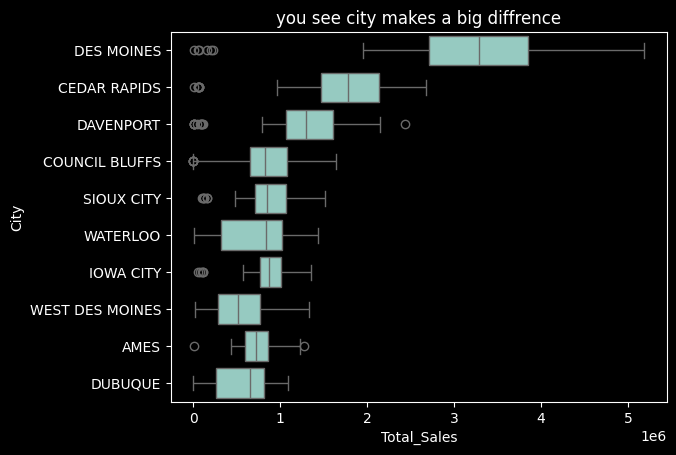

In [23]:
 by_month=df.groupby('City')['Total_Sales'].sum().nlargest(10).index
df_top10cities=df[df['City'].isin(by_month)]
sns.boxplot(x='Total_Sales',y='City',data=df_top10cities)
plt.title('you see city makes a big diffrence')


<Axes: xlabel='Month', ylabel='Total_Sales'>

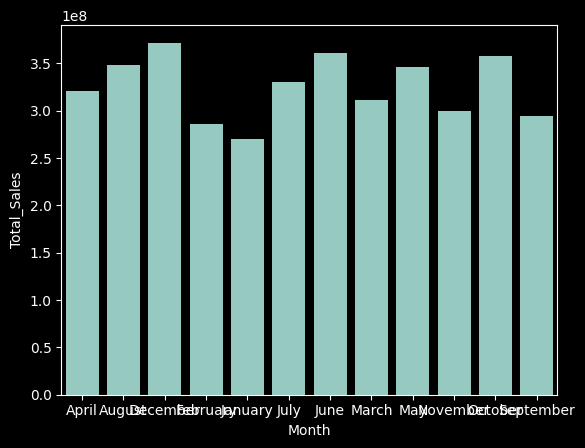

In [24]:
bymonth=df.groupby('Month')['Total_Sales'].sum().reset_index()
bymonth.head()
sns.barplot(x='Month',y="Total_Sales",data=bymonth)

In [25]:
top10countys=df.groupby('County')['Total_Sales'].sum().nlargest(10).index
top10countys

Index(['POLK', 'LINN', 'SCOTT', 'JOHNSON', 'BLACK HAWK', 'POTTAWATTAMIE',
       'WOODBURY', 'STORY', 'DUBUQUE', 'DALLAS'],
      dtype='object', name='County')

Text(0.5, 1.0, 'we see it not the same for Couty')

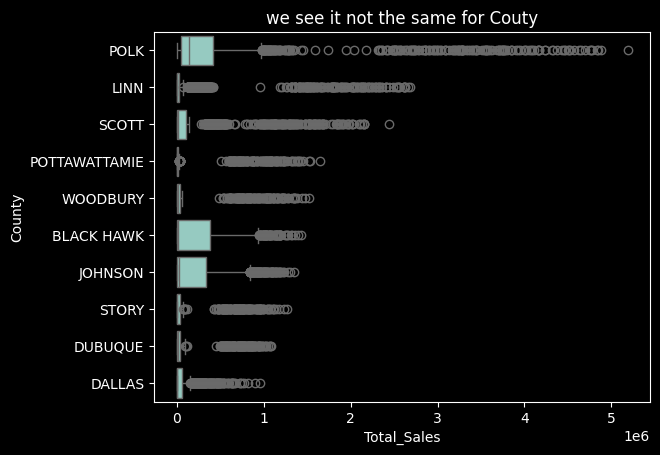

In [26]:
dftop10county=df[df['County'].isin(top10countys)]
sns.boxplot(x='Total_Sales',y='County',data=dftop10county)
plt.title('we see it not the same for Couty')

Text(0.5, 1.0, 'we see that having more stores in your city doesnt help')

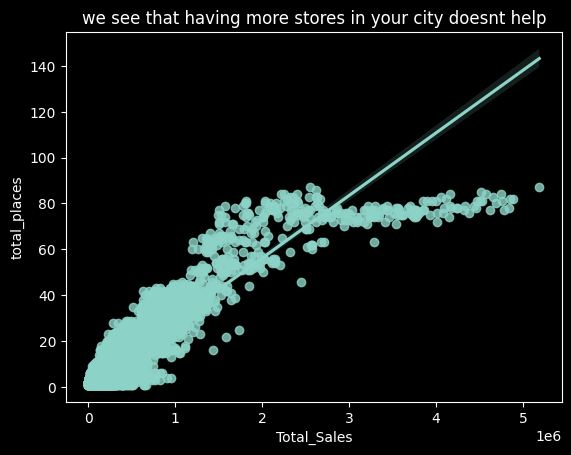

In [27]:
sns.regplot(x='Total_Sales',y='total_places',data=df)
plt.title('we see that having more stores in your city doesnt help')

Text(0.5, 1.0, 'we see there still a something in the avge months but very low for city as we saw before')

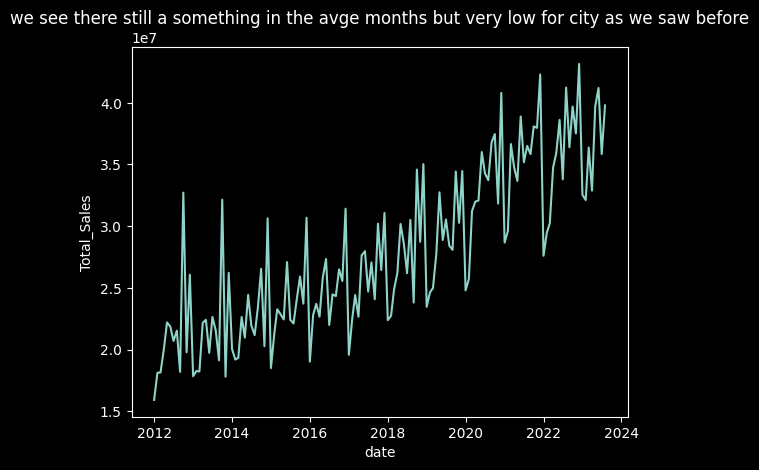

In [28]:
# 
monthly_plot_data = df.groupby('date')['Total_Sales'].sum().reset_index()


sns.lineplot(x='date', y='Total_Sales', data=monthly_plot_data)
plt.title('we see there still a something in the avge months but very low for city as we saw before')

Text(0.5, 1.0, 'avge sales per city')

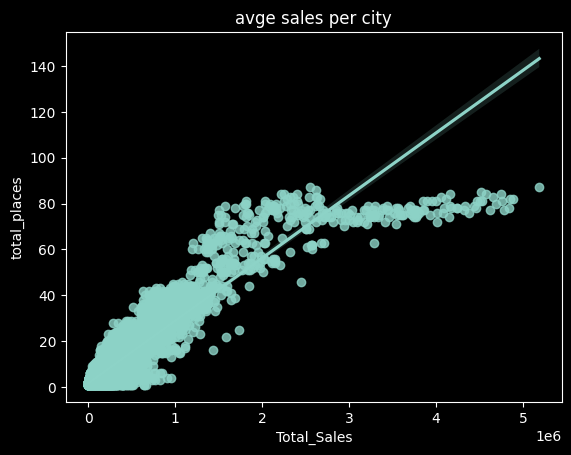

In [29]:
sns.regplot(x='Total_Sales',y='total_places',data=df)
plt.title('avge sales per city')

In [30]:
# Check the raw count in the table you created
print(con.execute("SELECT COUNT(*) FROM sales_data").df())

   count_star()
0      27197819
